# SI 385 Group Project Analysis Notebook

### Analysis of NFL Stadium Attendance

###### Matthew Urbanczyk, Emily Adamo, Sam Gibson

## 1. Reading in and Cleaning Data

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [16]:
games = pd.read_csv('/Users/samgibson/Desktop/si385fa2025/data/games.csv')

In [17]:
games['thediff'] = games['turnovers_loss'] - games['turnovers_win']

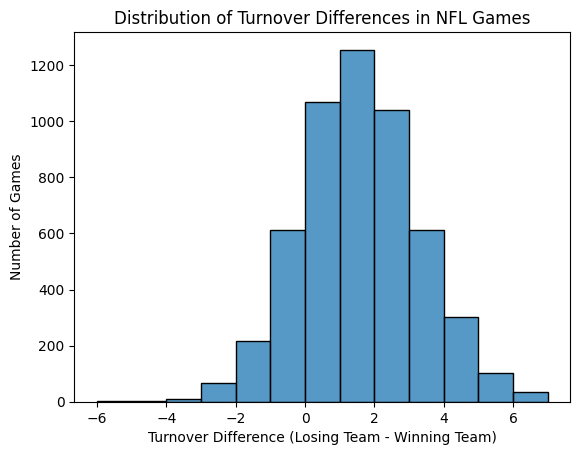

In [18]:
sns.histplot(games['thediff'], binwidth=1)
plt.title('Distribution of Turnover Differences in NFL Games')
plt.xlabel('Turnover Difference (Losing Team - Winning Team)')
plt.ylabel('Number of Games')
plt.show()

In [ ]:
pctpos = games[games['thediff']>0].shape[0]/games.shape[0]
pctneg = games[games['thediff']<0].shape[0]/games.shape[0]
pctsame = games[games['thediff']==0].shape[0]/games.shape[0]

print(f"Percentage of games where winning team had fewer turnovers: {pctpos:.2%}")
print(f"Percentage of games where winning team had more turnovers: {pctneg:.2%}")
print(f"Percentage of games where turnovers were equal: {pctsame:.2%}")



Percentage of games where winning team had fewer turnovers: 62.85%
Percentage of games where winning team had more turnovers: 17.09%
Percentage of games where turnovers were equal: 20.06%


Percentage of games where winning team had fewer turnovers: 62.85%
Percentage of games where winning team had more turnovers: 17.09%
Percentage of games where turnovers were equal: 20.06%


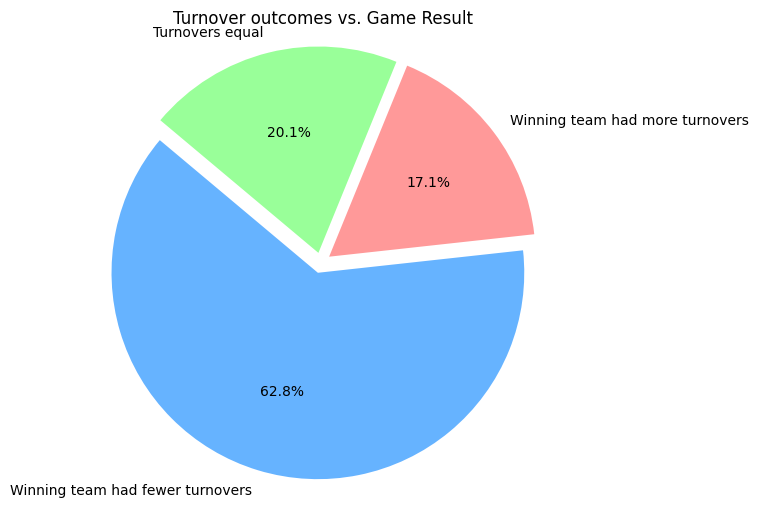

In [21]:
pctpos = games[games['thediff']>0].shape[0]/games.shape[0]
pctneg = games[games['thediff']<0].shape[0]/games.shape[0]
pctsame = games[games['thediff']==0].shape[0]/games.shape[0]

print(f"Percentage of games where winning team had fewer turnovers: {pctpos:.2%}")
print(f"Percentage of games where winning team had more turnovers: {pctneg:.2%}")
print(f"Percentage of games where turnovers were equal: {pctsame:.2%}")

labels = ['Winning team had fewer turnovers', 'Winning team had more turnovers', 'Turnovers equal']
sizes = [pctpos, pctneg, pctsame]
colors = ['#66b3ff', '#ff9999', '#99ff99']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode)
plt.title('Turnover outcomes vs. Game Result')
plt.axis('equal')
plt.show()

/var/folders/2c/58kkf5_j4hb1ffv34sx5q_q00000gn/T/ipykernel_64306/4197161288.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_year_ext = games.groupby('year').apply(lambda g: pd.Series({


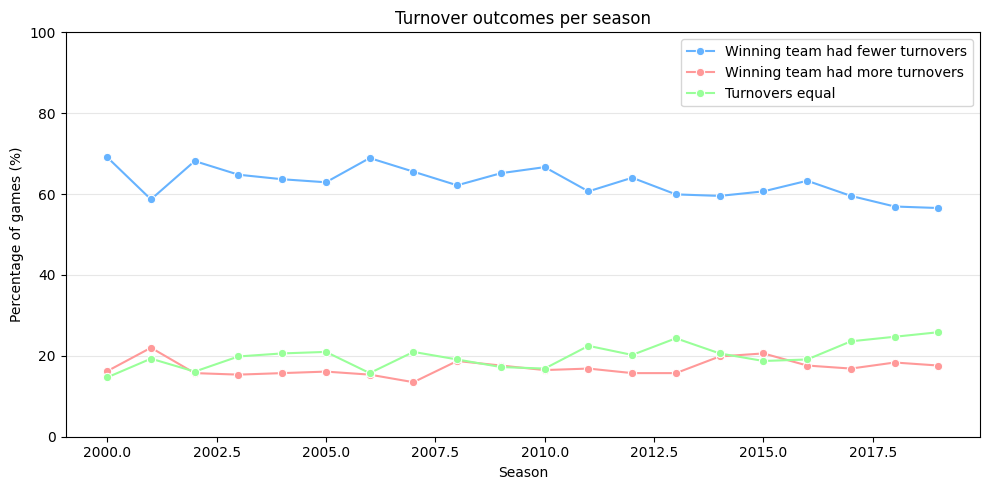

In [24]:
per_year_ext = games.groupby('year').apply(lambda g: pd.Series({
    'games': len(g),
    'win_fewer_turnovers': (g['thediff'] > 0).sum(),
    'win_more_turnovers': (g['thediff'] < 0).sum(),
    'win_same_turnovers': (g['thediff'] == 0).sum()
})).reset_index()

per_year_ext['pct_fewer'] = per_year_ext['win_fewer_turnovers'] / per_year_ext['games'] * 100
per_year_ext['pct_more']  = per_year_ext['win_more_turnovers']  / per_year_ext['games'] * 100
per_year_ext['pct_same']  = per_year_ext['win_same_turnovers']  / per_year_ext['games'] * 100

plt.figure(figsize=(10,5))
sns.lineplot(data=per_year_ext, x='year', y='pct_fewer', marker='o', color=colors[0], label='Winning team had fewer turnovers')
sns.lineplot(data=per_year_ext, x='year', y='pct_more',  marker='o', color=colors[1], label='Winning team had more turnovers')
sns.lineplot(data=per_year_ext, x='year', y='pct_same',  marker='o', color=colors[2], label='Turnovers equal')

plt.title('Turnover outcomes per season')
plt.xlabel('Season')
plt.ylabel('Percentage of games (%)')
plt.ylim(0,100)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()